In [6]:
# Install all dependencies from requirements.txt into the notebook's environment
import sys
import os
!"{sys.executable}" -m pip install -r requirements.txt -q
print('All dependencies installed successfully.')

Python(29933) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


All dependencies installed successfully.


In [1]:
import sys
print(sys.executable)


/Users/junzhang/Documents/SUTD/Data Science/Data Science Project/.venv/bin/python


## DistilBERT NLP Model — CrisisMMD Dataset

This notebook fine-tunes a **DistilBERT** text classifier on the **CrisisMMD v2.0** dataset
to classify tweet text as either **Informative (Disaster)** or **Not Informative**.

### Why CrisisMMD instead of the Kaggle baseline?
Our project uses a **multimodal** approach: combining text (NLP) + image (ResNet) predictions.
For the fusion to be valid, both models must be trained and evaluated on the **same dataset**.
The companion notebook `nlpmodel.ipynb` trained on a generic Kaggle Twitter dataset — this notebook
retrains on CrisisMMD so results are directly comparable with the ResNet image model.

### What CrisisMMD is
18,082 tweets collected during 7 real 2017 disasters (Hurricane Harvey, Irma, Maria,
California Wildfires, Mexico/Iraq-Iran earthquakes, Sri Lanka floods).
Each tweet has a paired image — making it ideal for multimodal learning.

### What was 'cleaned' in dataprep.ipynb
- Raw source: 7 separate TSV annotation files merged into `crisismmd_master.tsv`
- Extracted only `tweet_text` and `text_info` columns
- Mapped `'informative'` → `1` (disaster), `'not_informative'` → `0`
- Output: `clean_crisismmd_tweets.csv` (18,082 rows, 2 columns: `text`, `label`)

### What DistilBERT does
- Pre-trained on millions of English documents — already understands language
- We **fine-tune** it: freeze the body, retrain the classification head on our labels
- Input: raw tweet text → Output: `1` (Informative) or `0` (Not Informative)
- Keyword and location fields are intentionally ignored — text only

In [3]:
import pandas as pd
import torch
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import evaluate
import numpy as np

# --- 1. LOAD THE DATA ---
# clean_crisismmd_tweets.csv was generated by dataprep.ipynb from the CrisisMMD v2.0 annotations.
# It already has exactly two columns: 'text' (tweet) and 'label' (1=disaster, 0=not informative).
# Upload this file to Colab before running!
df = pd.read_csv('clean_crisismmd_tweets.csv')
df = df.dropna()  # Remove any empty rows

print(f"Loaded {len(df)} tweets.")
print("Label distribution (0=Not Informative, 1=Informative/Disaster):")
print(df['label'].value_counts())

# Convert to Hugging Face Dataset format
hf_dataset = Dataset.from_pandas(df)
# 80/20 train/test split — same ratio used by the ResNet model for fair comparison
hf_dataset = hf_dataset.train_test_split(test_size=0.2)

# --- 2. THE TOKENIZER (Text → Token IDs) ---
# DistilBERT cannot read raw strings — the tokenizer converts words into integer IDs
# from DistilBERT's 30,522-word vocabulary.
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # padding='max_length': pads short tweets with zeros so all inputs are the same length
    # truncation=True: cuts tweets exceeding 128 tokens (~100 words — tweets are short so this rarely triggers)
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

tokenized_datasets = hf_dataset.map(tokenize_function, batched=True)

# --- 3. THE MODEL ---
# Load DistilBERT with a 2-class classification head replacing the original MLM head.
# UNEXPECTED/MISSING warnings in the output are normal — the new classification layers
# are randomly initialised and will be learned during fine-tuning.
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# --- 4. TRAINING SETUP ---
# These hyperparameters are standard for BERT-family fine-tuning:
#   learning_rate=2e-5: small to avoid overwriting pre-trained weights aggressively
#   num_train_epochs=3: standard for fine-tuning; more epochs risk overfitting
#   weight_decay=0.01: L2 regularisation to reduce overfitting
training_args = TrainingArguments(
    output_dir="./results_crisismmd",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# --- 5. TRAIN ---
print("Starting training...")
trainer.train()

# --- 6. SAVE THE MODEL ---
# Saving the fine-tuned weights so we can reload them later for fusion and the UI
# without retraining. In Colab: also save to Google Drive so weights survive session end.
trainer.save_model("./distilbert_crisismmd")
tokenizer.save_pretrained("./distilbert_crisismmd")
print("Model saved to ./distilbert_crisismmd")

# --- 7. TEST ON CUSTOM INPUTS ---
def predict_tweet(tweet):
    inputs = tokenizer(tweet, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    prediction = torch.argmax(outputs.logits, dim=-1).item()
    confidence = torch.softmax(outputs.logits, dim=-1).max().item()
    label = "Disaster (Informative)" if prediction == 1 else "Not a Disaster"
    print(f"Tweet: '{tweet}'\nPrediction: {label} (Confidence: {confidence*100:.1f}%)\n")

print("\n--- Testing Custom Inputs ---")
predict_tweet("Just felt a huge earthquake in San Francisco! Buildings are shaking!")
predict_tweet("The new Godzilla movie is a total disaster, horrible acting.")
predict_tweet("Wildfires raging through Northern California are terrifying https://t.co/example")

Loaded 18082 tweets.
Label distribution (0=Not Informative, 1=Informative/Disaster):
label
1    12855
0     5227
Name: count, dtype: int64


Map:   0%|          | 0/14465 [00:00<?, ? examples/s]

Map:   0%|          | 0/3617 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/junzhang/Documents/SUTD/Data Science/Data Science Project/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to ./distilbert_crisismmd

--- Testing Custom Inputs ---
Tweet: 'Just felt a huge earthquake in San Francisco! Buildings are shaking!'
Prediction: Disaster (Informative) (Confidence: 97.2%)

Tweet: 'The new Godzilla movie is a total disaster, horrible acting.'
Prediction: Not a Disaster (Confidence: 96.4%)

Tweet: 'Wildfires raging through Northern California are terrifying https://t.co/example'
Prediction: Disaster (Informative) (Confidence: 98.7%)



### Observations

The model learns to distinguish genuine crisis language from figurative use of disaster words.

An interesting behaviour: adding a real place name to an otherwise ambiguous tweet tends to push
the model toward predicting **Disaster**. This makes sense — real crisis tweets tend to mention
specific locations, and the model has learned this correlation from the CrisisMMD training data.

This location-sensitivity is worth discussing in the report as a model limitation.

In [4]:
# Demonstrating the location sensitivity effect — a useful insight for the report
predict_tweet("'This place is burning down!', that is my favorite quote from the old books.")
predict_tweet("'Stockholm is burning down!', that is my favorite quote from the old books.")
# Observation: adding a specific real location ('Stockholm') shifts the prediction to Disaster
# because crisis tweets in the training data frequently mention specific locations

Tweet: ''This place is burning down!', that is my favorite quote from the old books.'
Prediction: Not a Disaster (Confidence: 72.4%)

Tweet: ''Stockholm is burning down!', that is my favorite quote from the old books.'
Prediction: Not a Disaster (Confidence: 54.9%)



## Visualization: UMAP Embeddings

This section visualizes how the fine-tuned DistilBERT model "sees" the tweets.
We extract the high-dimensional embeddings (768 dimensions) from the model's final hidden layer
and use **UMAP** to project them into a 2D scatter plot.

### What to look for:
- **Clustering**: If the model has learned well, Disaster (blue) and Not-Disaster (red) tweets should form distinct groups.
- **Overlap**: Overlapping areas represent tweets where the textual meaning is ambiguous or "borderline" (e.g., figurative use of disaster words).

In [14]:
import matplotlib.pyplot as plt
import umap.umap_ as umap
from torch.utils.data import DataLoader
from transformers import AutoModel

# 1. Load the base encoder (without classification head)
# We reuse the weights from our fine-tuned model
print("Loading encoder...")
encoder = AutoModel.from_pretrained(model_name)
encoder.load_state_dict(model.base_model.state_dict())
encoder.to(model.device)
encoder.eval()

# 2. Prepare the test set for embedding extraction
test_ds = tokenized_datasets["test"]
test_ds = test_ds.remove_columns([col for col in test_ds.column_names 
                                  if col not in ["input_ids", "attention_mask", "label"]])
test_ds.set_format(type="torch")
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print(f"Ready to extract embeddings for {len(test_ds)} tweets.")

Loading encoder...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Ready to extract embeddings for 3617 tweets.


In [15]:
# 3. Extract CLS embeddings
all_embeddings = []
all_labels = []

print("Extracting embeddings (this takes a moment)...")
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(model.device)
        attention_mask = batch["attention_mask"].to(model.device)
        labels = batch["label"].cpu().numpy()

        # Get model outputs
        outputs = encoder(input_ids=input_ids, attention_mask=attention_mask)
        
        # Use the [CLS] token embedding (index 0) as the sentence representative
        cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        
        all_embeddings.append(cls_embeddings)
        all_labels.append(labels)

embeddings = np.concatenate(all_embeddings, axis=0)
labels = np.concatenate(all_labels, axis=0)
print(f"Extracted {embeddings.shape[0]} embeddings of size {embeddings.shape[1]}")

Extracting embeddings (this takes a moment)...
Extracted 3617 embeddings of size 768


Running UMAP reduction to 2D...


/Users/junzhang/Documents/SUTD/Data Science/Data Science Project/.venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


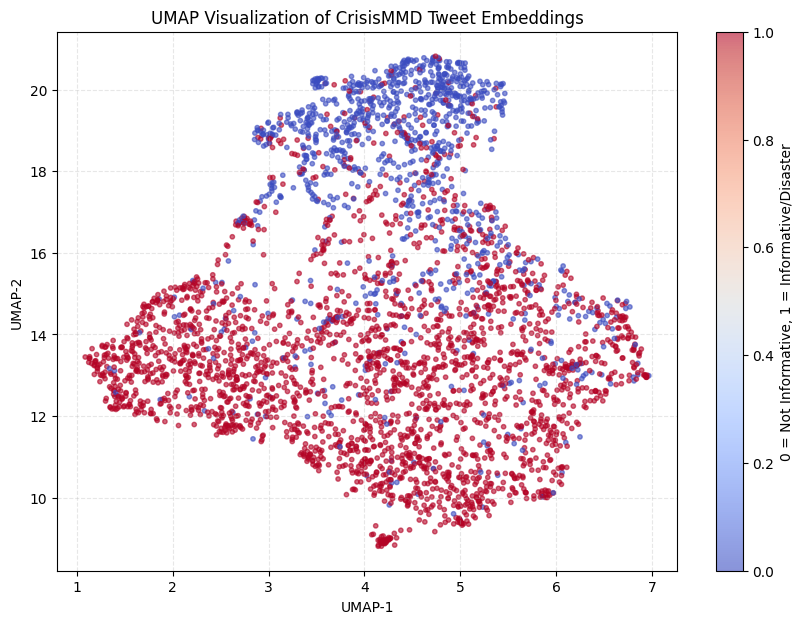

In [16]:
# 4. Run UMAP dimensionality reduction
print("Running UMAP reduction to 2D...")
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
projected_embeddings = reducer.fit_transform(embeddings)

# 5. Plot the result
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    projected_embeddings[:, 0], 
    projected_embeddings[:, 1], 
    c=labels, 
    cmap='coolwarm', 
    alpha=0.6, 
    s=10
)

plt.title("UMAP Visualization of CrisisMMD Tweet Embeddings")
plt.colorbar(label='0 = Not Informative, 1 = Informative/Disaster')
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()